# Figure 7 of Pierard2024TheTile: Behavior of Other Scores

In [1]:
from sorbetto.tile import CorrelationTile
from sorbetto.flavor import CorrelationFlavor
from sorbetto.performance import TwoClassClassificationPerformance
from sorbetto.performance.distribution import UniformDistributionOfTwoClassClassificationPerformancesForFixedClassPriors
from sorbetto.parameterization import ParameterizationDefault
from sorbetto.annotation import AnnotationText, AnnotationGridShiftClassPriors, AnnotationCurveFixedClassPriors, AnnotationMax, AnnotationGeometric
from sorbetto.ranking import RankingScore

import matplotlib.pyplot as plt

In [2]:
def analyze_score ( score, score_name, prior_pos, num_performances = 1000 ) :

    distribution = UniformDistributionOfTwoClassClassificationPerformancesForFixedClassPriors ( prior_pos )
    num_performances = 1000
    performances = distribution.drawAtRandom ( num_performances )
    
    correlation_coefficient = "kendall_tau"
    #flavor_name = 'Correlation between the score "{}" and {}'.format ( score_name, "$R_{I}$" )
    flavor_name = 'τ({} ; {})'.format ( score_name, "$R_{I}$" )
    flavor = CorrelationFlavor ( performances, score, correlation_coefficient, flavor_name )
    
    parameterization = ParameterizationDefault ()
    tile_name = 'Correlation Tile for $\\pi_+={:g}$ (approx. with {} perfs.)'.format ( prior_pos, num_performances )
    tile = CorrelationTile ( parameterization, flavor, resolution=101, name=tile_name )
    
    annotation = AnnotationGridShiftClassPriors (0.5, prior_pos, linestyle='-' )
    tile.appendAnnotation ( annotation )
    
    annotation = AnnotationCurveFixedClassPriors (prior_pos, color='k' )
    tile.appendAnnotation ( annotation )
    
    annotation = AnnotationMax ( color='k' )
    tile.appendAnnotation ( annotation )
    
    return tile

## A new look at the balanced accuracy

Got : AssertionError().

/Users/pierard/Documents/GitHub/sorbetto/examples/sorbetto/geometry/line_segment.py:65: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([p1.x, p2.x], [p1.y, p2.y], "-", **options_for_plot)


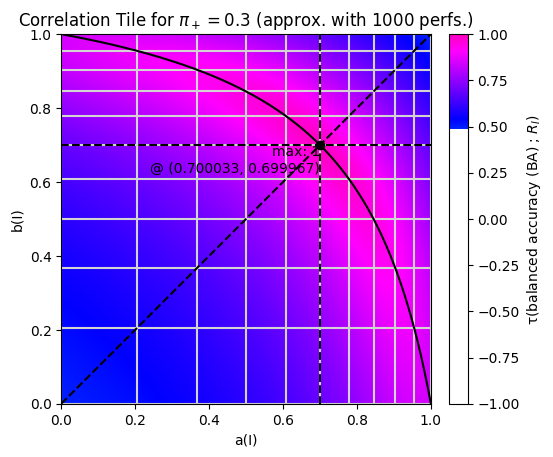

In [3]:
def balanced_accuracy ( performance ) :
    assert isinstance ( performance, TwoClassClassificationPerformance )
    tnr = performance.ptn / ( performance.ptn + performance.pfp )
    tpr = performance.ptp / ( performance.pfn + performance.ptp )
    return 0.5 * ( tnr + tpr )

score = balanced_accuracy
score_name = "balanced accuracy (BA)"
prior_pos = 0.3
tile = analyze_score ( score, score_name, prior_pos )

# Great, we have the Tile with already some annotations on top of it.
# But before drawing it, we'd like to add a few supplementary annotations.

itn = prior_pos
itp = 1.0 - prior_pos
locus = tile.parameterization.locateRelativeImportanceSatisfying(itn, itp)
annotation = AnnotationGeometric ( locus, linestyle='--', color='k' )
tile.appendAnnotation ( annotation )

ifp = prior_pos
ifn = 1.0 - prior_pos
locus = tile.parameterization.locateRelativeImportanceUnsatisfying(ifp, ifn)
annotation = AnnotationGeometric ( locus, linestyle='--', color='k' )
tile.appendAnnotation ( annotation )

locus = tile.parameterization.locateOrderingsInvertedWithOpChangePredictedClass()
annotation = AnnotationGeometric ( locus, linestyle='--', color='k' )
tile.appendAnnotation ( annotation )

tile.draw ()
plt.show ()

## A new look at Cohen's Kappa

Got : AssertionError().



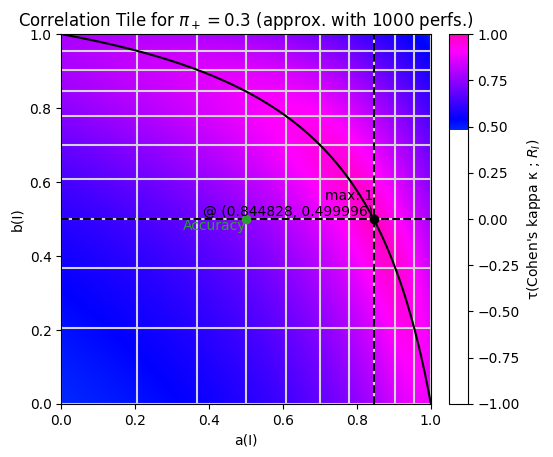

In [4]:
accuracy = RankingScore.getAccuracy()

def cohen_normalisation ( score ) :
    def normalized_score ( performance ) :
        assert isinstance ( performance, TwoClassClassificationPerformance )
        # We assume the maximal value of the score is 1.0 ...
        max_val = 1.0
        score_value = score ( performance )
        assert score_value <= max_val
        chance = score ( performance.toNoSkill () )
        return ( score_value - chance ) / ( max_val - chance )
    return normalized_score

cohen_kappa = cohen_normalisation ( accuracy )

score = cohen_kappa
score_name = "Cohen's kappa κ"
prior_pos = 0.3
tile = analyze_score ( score, score_name, prior_pos )

# Great, we have the Tile with already some annotations on top of it.
# But before drawing it, we'd like to add a few supplementary annotations.

itn = ( prior_pos ) ** 2.0
itp = ( 1.0 - prior_pos ) ** 2.0
locus = tile.parameterization.locateRelativeImportanceSatisfying(itn, itp)
annotation = AnnotationGeometric ( locus, linestyle='--', color='k' )
tile.appendAnnotation ( annotation )

ifp = 0.5
ifn = 0.5
locus = tile.parameterization.locateRelativeImportanceUnsatisfying(ifp, ifn)
annotation = AnnotationGeometric ( locus, linestyle='--', color='k' )
tile.appendAnnotation ( annotation )

annotation = AnnotationText ( accuracy, 'Accuracy', color='tab:green' )
tile.appendAnnotation ( annotation )

tile.draw ()
plt.show ()